# Regresion lineal coste de ciberseguridad

En este ejercicio se explicaran los funcamentos básicos de la regresión lineral aplicada a un caso de uso sencillo relacionado con la ciberseguridad]

## Enunciado del ejercicio
Este ejercicio consiste en predecir el costo de un incidente de seguridad en base al número de equipos que se han visto afectados. El conjunto de datos es generado de manera aleatoria.

In [48]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression

%matplotlib inline

### Generación del conjunto de datos

In [49]:
x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x +np.random.rand(100, 1)

print("La longitud del conjunto de datos es:", x.size)
print(y.size)


La longitud del conjunto de datos es: 100
100


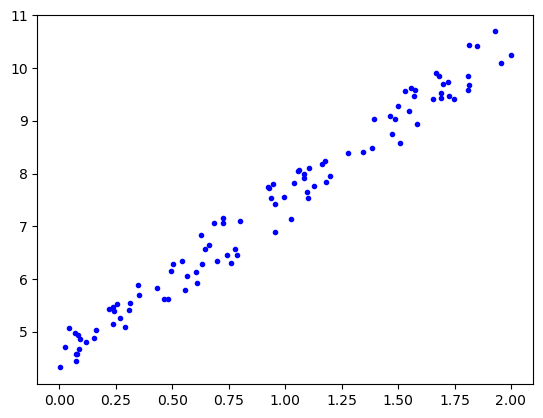

In [50]:
pl.plot(x, y, "b.")
pl.show()

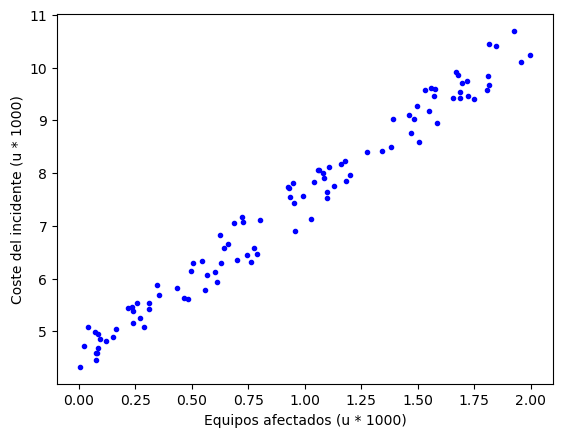

In [51]:
pl.plot(x, y, "b.")
pl.xlabel("Equipos afectados (u * 1000)")
pl.ylabel("Coste del incidente (u * 1000)")
pl.show()


### Modificación del conjunto de datos

Convertimos los datos a su valor real, en lugar de usar factores de conversión

In [52]:
data = { "n_equipos_afectados": x.flatten(), "costo_incidente_x_equipos": y.flatten() }

df = pd.DataFrame( data )

df.head()

,n_equipos_afectados,costo_incidente_x_equipos
0,0.799960,7.109784
1,0.255931,5.531816
2,1.668584,9.914185
3,0.354190,5.697800
4,0.924939,7.746324


In [53]:
# Escalado del número de equipos afectados a un valor mas real

df['n_equipos_afectados'] = df['n_equipos_afectados'] * 1000   
df['n_equipos_afectados'] = df['n_equipos_afectados'].astype('int') 

# Escalado del costo del incidente a un valor mas real

df['costo_incidente_x_equipos'] = df['costo_incidente_x_equipos'] * 10000   
df['costo_incidente_x_equipos'] = df['costo_incidente_x_equipos'].astype('int') 

df.head(10) 

,n_equipos_afectados,costo_incidente_x_equipos
0,799,71097
1,255,55318
2,1668,99141
3,354,56977
4,924,77463
5,1689,94320
6,629,62870
7,1484,90352
8,1810,98463
9,1039,78244


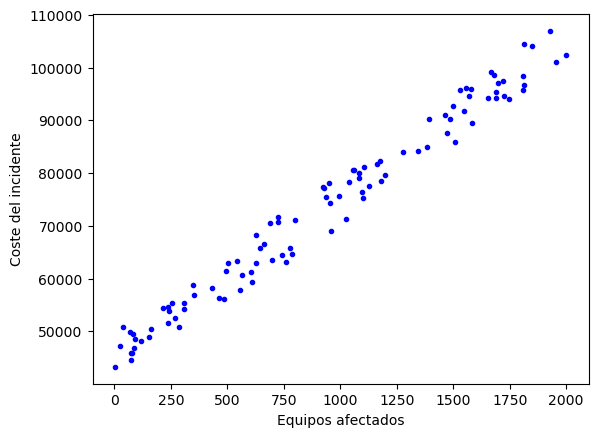

In [54]:
#Representación gráfica del conjunto de datos 

pl.plot( df['n_equipos_afectados'], df['costo_incidente_x_equipos'], "b." )
pl.xlabel("Equipos afectados")
pl.ylabel("Coste del incidente")
pl.show()

### Construcción del modelo

In [55]:
#Carga de modelo y ajuste de funcion hipotesis

lin_reg = LinearRegression()
lin_reg.fit( df['n_equipos_afectados'].values.reshape(-1, 1), df['costo_incidente_x_equipos'].values )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
# Que se muestre el valor que se le asigno al parámetro theta0 (Lugar donde cortaŕa el modelo con el eje y)

lin_reg.intercept_

np.float64(45428.47298619228)

In [57]:
# Que se muestre el valor que se le asigno al parámetro theta1 (La pendiente que tendrá el modelo de regresión)
lin_reg.coef_

array([30.0553795])

### Predicción para el valor minímo y máximo para el conjunto de datos de entrenamiento

In [58]:
xMinMax = np.array( [ [ df['n_equipos_afectados'].min() ], [ df['n_equipos_afectados'].max() ] ] )

yTrainPred = lin_reg.predict( xMinMax )



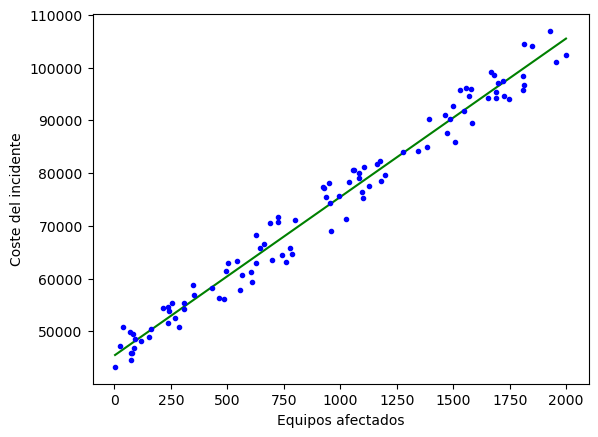

In [59]:
#Representación gráfica de la función hipotesis generada
 
pl.plot(xMinMax, yTrainPred, "g-")
pl.plot( df['n_equipos_afectados'], df['costo_incidente_x_equipos'], "b." )
pl.xlabel("Equipos afectados")
pl.ylabel("Coste del incidente")
pl.show()

### Predicción de nuevos ejemplos

In [60]:
xNew = np.array( [ [ 450 ] ] ) # Valor de 760 equipos afectados

# Realizando la predicción del coste que tendría este incidente
costo = lin_reg.predict( xNew )

print("el costo del incidente sería: $", int( costo[0] ) )


el costo del incidente sería: $ 58953


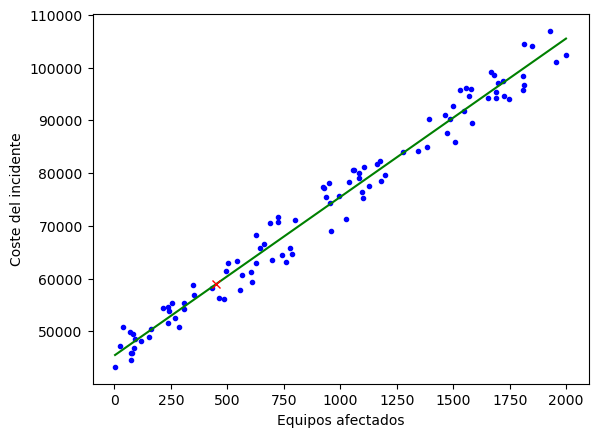

In [61]:
pl.plot( df['n_equipos_afectados'], df['costo_incidente_x_equipos'], "b." )
pl.plot(xMinMax, yTrainPred, "g-")
pl.plot( xNew, costo, "rx" )
pl.xlabel("Equipos afectados")
pl.ylabel("Coste del incidente")
pl.show()